In [1]:
#imports
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import pandas as pd
import numpy as np
import time

from dask.distributed import Client, LocalCluster
from formulaic import Formula

import scMPRAforge as scm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cluster=LocalCluster()
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

2025-07-03 11:45:33,119 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-_m6ku6o4', purging
2025-07-03 11:45:33,119 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-2etwlnk8', purging
2025-07-03 11:45:33,120 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-srrua8jm', purging
2025-07-03 11:45:33,120 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-xanvmx4m', purging
2025-07-03 11:45:33,120 - distributed.diskutils - INFO - Found stale lock file and directory '/var/folders/1d/0w58jwl11g91yrp_p3jm9fdw0000gn/T/dask-worker-space/worker-qvcz40og', purging
2025-07-03 11:45:33,121 - distributed.diskutils - INFO - Found st

In [4]:
shendure=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/shendure/shendure_counts_grouped.txt")

scMPRAforge: INFO: Dropping cell-types & cres with below 3 (MIN_PTS) observations: f{'cre_id': ['Col1a1_chr11_15306', 'Col1a2_chr6_65', 'minP_w_20bp_buffer'], 'cell_type': []}
scMPRAforge: INFO: Dropping 4990 cells with no MPRA UMIs, leaving 38457.


In [5]:
shendure_subset=shendure.data[shendure.data["cell_type"]=="EpiblastPrimitiveStreak"]
shendure_mean=shendure_subset.groupby("cre_id")["umis_mpra_bc"].agg("mean").sort_values()
shendure_mean

cre_id
Cited2_chr10_1239      0.000000
Txndc12_chr4_7969      0.000000
Tgfbi_chr13_5711       0.000000
Klf4_chr4_3952         0.000000
Sox17_chr1_68          0.000000
                        ...    
Tubb2b_chr13_2576      8.500901
Btg1_chr10_9578       11.981481
ubcP                  52.924898
pgk1P                153.751531
eef1aP               439.323718
Name: umis_mpra_bc, Length: 209, dtype: float64

In [8]:
def create_matricies(nb_formula,zi_formula,shared_formula,scmpra):
    """
    Takes a scMPRA_data object & formulas & produces design matricies. 
    """
    data=scmpra
    y, X=Formula(nb_formula).get_model_matrix(data,output='pandas')
    Z=Formula(zi_formula).get_model_matrix(data,output='pandas')
    S=Formula(shared_formula).get_model_matrix(data,output='pandas')
    return {
        'nb_regressors':X,
        'regressand':y,
        'zi_regressors':Z,
        'shared_regressors':S
    }

matricies=create_matricies(nb_formula="umis_mpra_bc ~ C(cre_id)-1+ln_cell_umis_mpra",
                           zi_formula="C(rep_id)-1+ln_cell_umis_mpra",
                           shared_formula='ln_cell_umis_mpra',
                           scmpra=shendure_subset)

In [9]:
def tensorzinb_fit(matricies):
    """
    Takes matricies as returned by `create_matricies` & produces a tensorzinb model
    """

    from tensorzinb.tensorzinb import TensorZINB

    zinbo = TensorZINB(endog=matricies["regressand"]["umis_mpra_bc"].to_numpy().reshape((-1, 1)),
                       exog=matricies["nb_regressors"],
                       exog_infl=matricies["zi_regressors"].to_numpy(),)
                       #exog_c=matricies["shared_regressors"],
                       #exog_infl_c=matricies["shared_regressors"])  # ,same_dispersion=True
    zinb_result = None
    try:
        zinb_result = zinbo.fit(init_method="nb")
    except InvalidIndexError:
        return "index_error"

    return zinb_result

model=tensorzinb_fit(matricies)

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB



In [10]:
model

{'llf_total': -56821.16334007494,
 'llfs': array([-56821.16334007]),
 'aic_total': 114078.32668014988,
 'aics': array([114078.32668015]),
 'df_model_total': 218,
 'df': 218,
 'weights': {'x_mu': array([[-4.756049  ],
         [-4.274292  ],
         [-5.291079  ],
         [-4.519158  ],
         [-0.93097925],
         [-4.517261  ],
         [-6.2863283 ],
         [-4.442332  ],
         [-4.3166723 ],
         [-5.4218035 ],
         [ 1.2235487 ],
         [-5.1721425 ],
         [-3.9967012 ],
         [-4.469335  ],
         [-5.075829  ],
         [-1.484417  ],
         [-0.05557705],
         [ 0.9133828 ],
         [-3.9277835 ],
         [-2.1005008 ],
         [-4.296527  ],
         [-5.075793  ],
         [-7.457805  ],
         [-4.3436275 ],
         [-5.864794  ],
         [-3.3704917 ],
         [-0.01735647],
         [-5.0582085 ],
         [-4.583827  ],
         [-2.6352608 ],
         [-3.9917727 ],
         [-4.1272492 ],
         [-2.3121204 ],
         [-4.56

In [11]:
matricies["nb_regressors"]

,C(cre_id)[Bend5_chr4_8168],C(cre_id)[Bend5_chr4_8170],C(cre_id)[Bend5_chr4_8172],C(cre_id)[Bend5_chr4_8174],C(cre_id)[Bend5_chr4_8175],C(cre_id)[Bend5_chr4_8179],C(cre_id)[Bend5_chr4_8192],C(cre_id)[Bend5_chr4_8199],C(cre_id)[Bend5_chr4_8201],C(cre_id)[Btg1_chr10_9572],...,C(cre_id)[Txndc12_chr4_7971],C(cre_id)[Txndc12_chr4_7973],C(cre_id)[Txndc12_chr4_7975],C(cre_id)[Txndc12_chr4_7978],C(cre_id)[eef1aP],C(cre_id)[minP],C(cre_id)[noP],C(cre_id)[pgk1P],C(cre_id)[ubcP],ln_cell_umis_mpra
9,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.197225
10,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,2.197225
11,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2.197225
12,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,2.197225
13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.197225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736477,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.890372
736478,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.890372
736479,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,2.890372
736480,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,2.890372


In [12]:
len(model["weights"]["x_mu"])

210

In [13]:
#x_mu * beta_g,mu
linear_mu=matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]

#x_mu * beta_g,mu + Z_mu * alpha_mu
#linear_mu=(matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]+
#        matricies["shared_regressors"].to_numpy() @ model["weights"]["z_mu"])
mu_predictions=np.exp(linear_mu)

#x_pi * beta_g,pi + Z_pi * alpha_pi
#linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"]+
#           matricies["shared_regressors"].to_numpy() @ model["weights"]["z_pi"])


#x_pi * beta_g,pi
linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"])
zi_predictions=linear_zi=1/(1+np.exp(-linear_zi))

In [14]:
cre_labeling=scm.undo_one_hot_encoding(matricies["nb_regressors"])["cre_id"]
cre_labeling=cre_labeling.str.removeprefix("T.")

In [15]:
mu_predictions_df=pd.DataFrame({'cre_id':cre_labeling,'mu':mu_predictions.squeeze()})
mu_predictions_df.sort_values(by='mu')

,cre_id,mu
352333,Foxa2_chr2_13858,0.000498
256066,Foxa2_chr2_13858,0.000498
83908,Foxa2_chr2_13858,0.000498
675333,Foxa2_chr2_13858,0.000498
327244,Col5a1_chr2_2586,0.000504
...,...,...
251503,eef1aP,630.339229
129094,eef1aP,631.196337
75414,eef1aP,633.817853
335071,eef1aP,637.017398


In [16]:
mu_summary=mu_predictions_df.groupby("cre_id").agg("mean")
mu_summary = mu_summary.merge(shendure_mean.rename_axis('cre_id').reset_index(), on='cre_id', how='left')
mu_summary.sort_values(by="mu")

,cre_id,mu,umis_mpra_bc
51,Col5a1_chr2_2586,0.001366,0.000000
199,Txndc12_chr4_7969,0.001451,0.000000
103,Klf4_chr4_3952,0.001579,0.000000
183,Tgfbi_chr13_5711,0.001644,0.000000
71,Foxa2_chr2_13858,0.001671,0.000000
...,...,...,...
190,Tubb2b_chr13_2576,8.012699,8.500901
10,Btg1_chr10_9578,11.576017,11.981481
208,ubcP,51.587454,52.924898
207,pgk1P,127.530585,153.751531


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

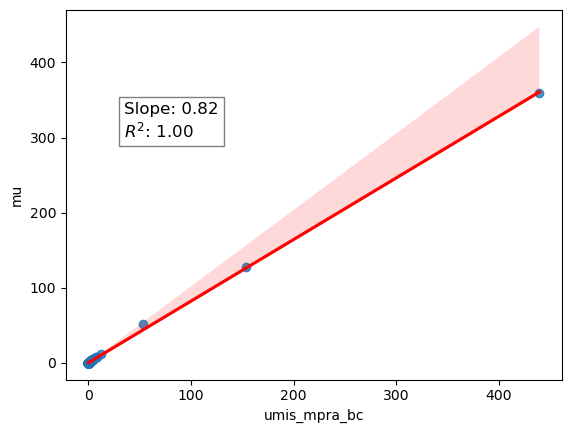

In [19]:
x = mu_summary["umis_mpra_bc"]
y = mu_summary["mu"]

# Fit regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Plot
sns.regplot(x=x, y=y, scatter=True, line_kws={"color": "red"})
plt.text(
    35, 300,  # coordinates for text box
    f"Slope: {slope:.2f}\n$R^2$: {r_value**2:.2f}",
    fontsize=12, bbox=dict(facecolor='white', alpha=0.5)
)

plt.show()


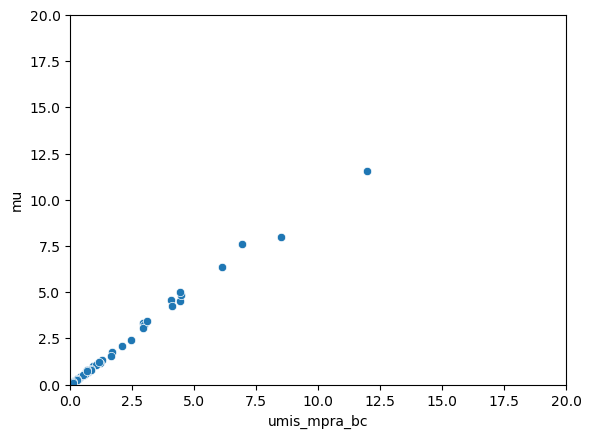

In [20]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 20)   # Set x-axis limits
plt.ylim(0, 20)   # Set y-axis limits
plt.show()

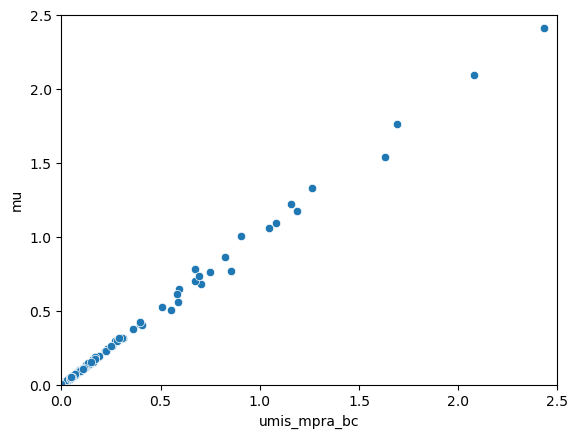

In [21]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 2.5)   # Set x-axis limits
plt.ylim(0, 2.5)   # Set y-axis limits
plt.show()

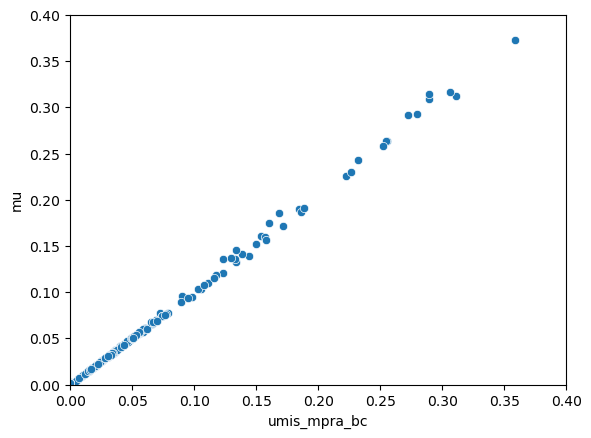

In [22]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 0.4)   # Set x-axis limits
plt.ylim(0, 0.4)   # Set y-axis limits
plt.show()

In [23]:
replicate_labeling=scm.undo_one_hot_encoding(matricies["zi_regressors"])["rep_id"]
replicate_labeling=replicate_labeling.str.removeprefix("T.")
zi_predictions_df=pd.DataFrame({'rep_id':replicate_labeling,'zi':zi_predictions.squeeze()})
zi_summary=zi_predictions_df.groupby("rep_id").agg("mean")
zi_summary




,zi
rep_id,
2B1,0.011028
2B2,0.002776
A1,0.018006
A2,0.010868
B1,0.005113
B2,0.012789


------

In [19]:
dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

scMPRAforge: INFO: [timed_fit] nobody took 0.67 seconds
scMPRAforge: INFO: [timed_fit] redgene took 0.88 seconds
scMPRAforge: INFO: [timed_fit] neurogene took 0.88 seconds
scMPRAforge: INFO: [timed_fit] everybody took 0.89 seconds
scMPRAforge: INFO: [timed_fit] somebody took 0.91 seconds
scMPRAforge: INFO: [timed_fit] brain took 0.99 seconds
scMPRAforge: INFO: [timed_fit] blood took 1.07 seconds


In [27]:
primordial.by_cell_type_parameters.result().theta

{'brain': array(1.3041191, dtype=float32),
 'blood': array(1.1990892, dtype=float32)}

In [49]:
cluster.close()